# 06 — Residue-level benchmarking & metrics

Per-residue evaluation of B-cell epitope predictors (BepiPred-3.0, DiscoTope-3.0,
ElliPro, GraphBepi, SEMA-3D) against IEDB ground truth, for linear and
conformational epitopes across bacterial organism groups (ESKAPE, GAST, INTRA, RESP).

**Evaluation design (read before interpreting any number):**

- **Threshold-free metrics (ROC-AUC, PR-AUC) are the primary, cross-comparable results.**
  They measure ranking/discrimination and do not depend on each tool's cutoff.
- **Threshold-based metrics (F1, MCC, BACC, Precision, Recall, Accuracy) are reported twice:**
  1. *Native cutoff* — using each tool's own default threshold (the shipped `y_pred`).
     These are **NOT comparable across models** — they reflect default calibration, not skill.
  2. *Matched budget* — for each protein, the top-N residues by score are called positive,
     where N = that protein's true-epitope count. A fair, model-independent operating point
     that isolates ranking quality. (Precision ≈ Recall by construction.)
- All cross-model comparisons run on the **fair subset**: proteins (and residues) covered by
  *every* model, so no model is judged on a different set.
- Aggregation is reported **micro** (residue-pooled) and **macro** (per-protein mean).

*Not executed in this environment (data lives on BlueBEAR). Run top-to-bottom there.*


In [1]:
import ast
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    f1_score, matthews_corrcoef, balanced_accuracy_score,
    precision_score, recall_score, accuracy_score, confusion_matrix,
)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

ORGS = ["ESKAPE", "GAST", "INTRA", "RESP"]

# display name -> output folder name
MODELS = {
    "BepiPred":  "bepipred3",
    "DiscoTope": "discotope3",
    "ElliPro":   "ellipro",
    "GraphBepi": "graphbepi",
    "SEMAi":     "sema",
    "RoBep":      "robep",
    "BepiPred2.0": "bepipred2",
}
MODEL_LIST = list(MODELS)        # never reassign this name elsewhere
TYPES = ["linear", "conformational"]

OUTPUTS = Path("../outputs")
IEDB = Path("../iedb")


## 1. Ground-truth labeling

`res_index` (predictions) and IEDB `start_pos`/`end_pos`/`residue_set` share the same
1-based UniProt numbering, so labeling is a direct match — no remapping.

In [2]:
def add_linear_truth(pred, gt):
    pred = pred.copy()
    pred["y_true"] = 0
    for _, row in gt.iterrows():
        uniprot = str(row["uniprot_accession"]).strip()
        start = int(row["start_pos"])
        end = int(row["end_pos"])
        mask = (
            (pred["uniprot"] == uniprot)
            & (pred["res_index"] >= start)
            & (pred["res_index"] <= end)
        )
        pred.loc[mask, "y_true"] = 1
    return pred


def parse_set(x):
    try:
        return set(map(int, ast.literal_eval(str(x))))
    except Exception:
        return set()


def add_conf_truth(pred, gt):
    pred = pred.copy()
    pred["y_true"] = 0
    for _, row in gt.iterrows():
        uniprot = str(row["uniprot_accession"]).strip()
        residues = parse_set(row["residue_set"])
        mask = (pred["uniprot"] == uniprot) & (pred["res_index"].isin(residues))
        pred.loc[mask, "y_true"] = 1
    return pred


## 2. Assemble `master`

Robust loading: missing files are recorded explicitly; any *other* read/labeling error
is allowed to raise (a bare `except` previously hid real bugs as "Skipped").

In [3]:
all_dfs, skipped = [], []

for name, folder in MODELS.items():
    for org in ORGS:
        for typ in TYPES:
            pred_path = OUTPUTS / folder / org / typ / f"{folder}_indexed.csv"
            gt_path = IEDB / org / typ / f"{typ}_ground_truth.csv"
            if not pred_path.exists() or not gt_path.exists():
                skipped.append((name, org, typ))
                continue
            pred = pd.read_csv(pred_path)
            gt = pd.read_csv(gt_path)
            df = add_linear_truth(pred, gt) if typ == "linear" else add_conf_truth(pred, gt)
            df["model"] = name
            df["organism"] = org
            df["type"] = typ
            all_dfs.append(df)

master = pd.concat(all_dfs, ignore_index=True)
print("master shape:", master.shape)
if skipped:
    print("Missing (model, org, type):")
    for s in skipped:
        print("  ", s)


master shape: (1145690, 33)


## 3. Sanity checks

Catch silent failures before any metric: required columns, duplicate residues,
per-model coverage, and a score-orientation check (pooled AUC < 0.5 ⇒ score may be inverted).

In [4]:
# required columns
required = {"uniprot", "res_index", "score", "y_pred", "y_true"}
missing = required - set(master.columns)
assert not missing, f"master is missing columns: {missing}"

# duplicate residues
dups = master.duplicated(["model", "type", "uniprot", "res_index"]).sum()
print("duplicate (model,type,uniprot,res_index) rows:", dups)

# coverage
cov = (
    master.groupby(["type", "model"])
    .agg(proteins=("uniprot", "nunique"),
         residues=("res_index", "size"),
         positives=("y_true", "sum"))
    .reset_index()
)
cov["prevalence"] = (cov["positives"] / cov["residues"]).round(4)
print(cov.to_string(index=False))

# score orientation
print("\nScore-orientation check (pooled ROC-AUC; <0.5 => verify score direction):")
for (typ, m), sub in master.groupby(["type", "model"]):
    yt = sub["y_true"].astype(int)
    if yt.nunique() < 2:
        continue
    auc = roc_auc_score(yt, sub["score"].astype(float))
    flag = "   <-- CHECK ORIENTATION" if auc < 0.5 else ""
    print(f"  {typ:15s} {m:10s} AUC={auc:.3f}{flag}")


duplicate (model,type,uniprot,res_index) rows: 0
          type       model  proteins  residues  positives  prevalence
conformational    BepiPred        38     17223        904      0.0525
conformational BepiPred2.0        38     17223        904      0.0525
conformational   DiscoTope        38     17223        904      0.0525
conformational     ElliPro        38     17223        904      0.0525
conformational   GraphBepi        36     13513        850      0.0629
conformational       RoBep        38     17223        904      0.0525
conformational       SEMAi        38     17223        904      0.0525
        linear    BepiPred       350    161721      21556      0.1333
        linear BepiPred2.0       350    161731      21558      0.1333
        linear   DiscoTope       337    146404      20675      0.1412
        linear     ElliPro       337    146404      20675      0.1412
        linear   GraphBepi       320    119771      19533      0.1631
        linear       RoBep       337    1

## 4. Fair subset

Restrict to proteins covered by every model **and** to residues `(uniprot, res_index)`
present for every model. This guarantees identical N per model within each type — the
previous version matched only on proteins, leaving small per-model residue differences.

In [5]:
def fair_subset(df, typ, model_list):
    sub = df[df["type"] == typ].copy()
    prot_sets = [set(sub.loc[sub.model == m, "uniprot"].unique()) for m in model_list]
    common_prot = set.intersection(*prot_sets)
    sub = sub[sub["uniprot"].isin(common_prot)].copy()
    sub["key"] = list(zip(sub["uniprot"], sub["res_index"]))
    res_sets = [set(sub.loc[sub.model == m, "key"]) for m in model_list]
    common_res = set.intersection(*res_sets)
    sub = sub[sub["key"].isin(common_res)].drop(columns="key")
    return sub, common_prot


linear_fair, common_linear = fair_subset(master, "linear", MODEL_LIST)
conf_fair, common_conf = fair_subset(master, "conformational", MODEL_LIST)
master_fair = pd.concat([linear_fair, conf_fair], ignore_index=True)

print("linear  common proteins:", len(common_linear))
print("conf    common proteins:", len(common_conf))
print(master_fair.groupby(["type", "model"]).size())   # identical within type


linear  common proteins: 319
conf    common proteins: 36
type            model      
conformational  BepiPred        13513
                BepiPred2.0     13513
                DiscoTope       13513
                ElliPro         13513
                GraphBepi       13513
                RoBep           13513
                SEMAi           13513
linear          BepiPred       119464
                BepiPred2.0    119464
                DiscoTope      119464
                ElliPro        119464
                GraphBepi      119464
                RoBep          119464
                SEMAi          119464
dtype: int64


## 5. Operating points

`y_pred` = native default cutoff (already in the data).
`y_pred_matched` = prevalence-matched top-N per protein (fair common operating point).

In [6]:
def add_matched_budget(df):
    # per (model, type, protein): top-N residues by score are positive,
    # N = number of true epitope residues in that protein (oracle budget)
    df = df.copy()
    df["y_pred_matched"] = 0
    for _, sub in df.groupby(["model", "type", "uniprot"]):
        n_true = int(sub["y_true"].sum())
        if n_true > 0:
            idx = sub.sort_values("score", ascending=False).head(n_true).index
            df.loc[idx, "y_pred_matched"] = 1
    return df


master_fair = add_matched_budget(master_fair)
print("matched-budget positives per (type, model):")
print(master_fair.groupby(["type", "model"])["y_pred_matched"].sum())


matched-budget positives per (type, model):
type            model      
conformational  BepiPred         850
                BepiPred2.0      850
                DiscoTope        850
                ElliPro          850
                GraphBepi        850
                RoBep            850
                SEMAi            850
linear          BepiPred       19531
                BepiPred2.0    19531
                DiscoTope      19531
                ElliPro        19531
                GraphBepi      19531
                RoBep          19531
                SEMAi          19531
Name: y_pred_matched, dtype: int64


## 6. Threshold-free metrics — PRIMARY (cross-comparable)

ROC-AUC and PR-AUC, reported micro (residue-pooled) and macro (mean over per-protein values;
proteins with no positives are skipped). PR-AUC is the more informative headline given class
imbalance; note prevalence differs between linear and conformational, so PR-AUC is comparable
*within* a type, not across types.

In [7]:
def threshfree_micro(df):
    rows = []
    for (typ, m), sub in df.groupby(["type", "model"]):
        yt = sub["y_true"].astype(int)
        s = sub["score"].astype(float)
        two = yt.nunique() > 1
        rows.append({
            "type": typ, "model": m, "N": len(sub),
            "Positives": int(yt.sum()), "Prevalence": round(yt.mean(), 4),
            "ROC_AUC": roc_auc_score(yt, s) if two else np.nan,
            "PR_AUC": average_precision_score(yt, s) if two else np.nan,
        })
    return pd.DataFrame(rows)


def threshfree_macro(df):
    per = []
    for (typ, m, prot), sub in df.groupby(["type", "model", "uniprot"]):
        yt = sub["y_true"].astype(int)
        if yt.nunique() < 2:
            continue
        s = sub["score"].astype(float)
        per.append({"type": typ, "model": m, "uniprot": prot,
                    "ROC_AUC": roc_auc_score(yt, s),
                    "PR_AUC": average_precision_score(yt, s)})
    per = pd.DataFrame(per)
    return (per.groupby(["type", "model"])
               .agg(n_proteins=("uniprot", "nunique"),
                    ROC_AUC=("ROC_AUC", "mean"),
                    PR_AUC=("PR_AUC", "mean"))
               .reset_index())


tf_micro = threshfree_micro(master_fair)
tf_macro = threshfree_macro(master_fair)

print("THRESHOLD-FREE (micro / residue-pooled) -- primary, cross-comparable")
print(tf_micro.round(3).to_string(index=False))
print("\nTHRESHOLD-FREE (macro / per-protein mean)")
print(tf_macro.round(3).to_string(index=False))


THRESHOLD-FREE (micro / residue-pooled) -- primary, cross-comparable
          type       model      N  Positives  Prevalence  ROC_AUC  PR_AUC
conformational    BepiPred  13513        850       0.063    0.647   0.103
conformational BepiPred2.0  13513        850       0.063    0.502   0.061
conformational   DiscoTope  13513        850       0.063    0.622   0.097
conformational     ElliPro  13513        850       0.063    0.510   0.064
conformational   GraphBepi  13513        850       0.063    0.652   0.138
conformational       RoBep  13513        850       0.063    0.570   0.098
conformational       SEMAi  13513        850       0.063    0.619   0.107
        linear    BepiPred 119464      19531       0.164    0.639   0.266
        linear BepiPred2.0 119464      19531       0.164    0.532   0.181
        linear   DiscoTope 119464      19531       0.164    0.515   0.174
        linear     ElliPro 119464      19531       0.164    0.517   0.167
        linear   GraphBepi 119464      1953

### 6b. Combined micro AUC (linear + conformational pooled)

A single dataset-level number per model, pooling every residue from both tracks into one
ROC/PR curve. Caveat: the two tracks differ greatly in size and prevalence (linear ~119k
residues / higher prevalence vs conformational ~13k), so the combined **PR-AUC is dominated
by the linear track** and the combined **ROC-AUC is a length-weighted blend**. Treat this as a
coarse overall summary only — the per-type breakdown in 6 remains the interpretable result.
(Residues are pooled as observations; a protein annotated in both tracks contributes a row to
each, so this is pooled observations, not unique residues.)

In [8]:
def threshfree_micro_combined(df):
    rows = []
    for m, sub in df.groupby("model"):
        yt = sub["y_true"].astype(int)
        s = sub["score"].astype(float)
        two = yt.nunique() > 1
        rows.append({
            "model": m, "N": len(sub), "Positives": int(yt.sum()),
            "Prevalence": round(yt.mean(), 4),
            "ROC_AUC": roc_auc_score(yt, s) if two else np.nan,
            "PR_AUC": average_precision_score(yt, s) if two else np.nan,
        })
    return pd.DataFrame(rows)


tf_micro_combined = threshfree_micro_combined(master_fair)
print("THRESHOLD-FREE (micro, linear + conformational COMBINED) -- per model")
print(tf_micro_combined.round(3).to_string(index=False))


THRESHOLD-FREE (micro, linear + conformational COMBINED) -- per model
      model      N  Positives  Prevalence  ROC_AUC  PR_AUC
   BepiPred 132977      20381       0.153    0.638   0.242
BepiPred2.0 132977      20381       0.153    0.530   0.168
  DiscoTope 132977      20381       0.153    0.520   0.165
    ElliPro 132977      20381       0.153    0.516   0.156
  GraphBepi 132977      20381       0.153    0.560   0.190
      RoBep 132977      20381       0.153    0.525   0.167
      SEMAi 132977      20381       0.153    0.541   0.181


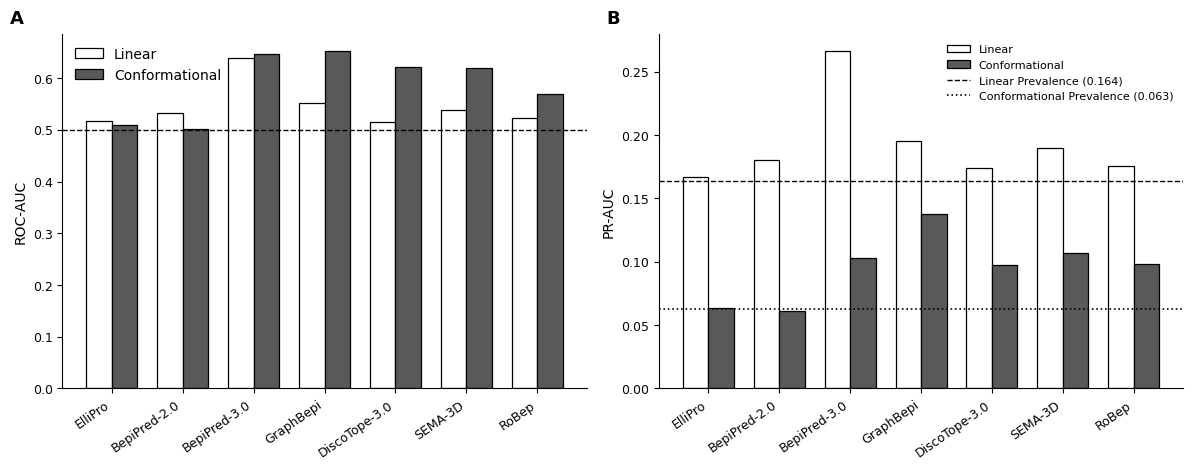

Ranking by micro-averaged ROC-AUC:
  Epitope type     Predictor  ROC-AUC  PR-AUC
Conformational     GraphBepi    0.652   0.138
Conformational  BepiPred-3.0    0.647   0.103
Conformational DiscoTope-3.0    0.622   0.097
Conformational       SEMA-3D    0.619   0.107
Conformational         RoBep    0.570   0.098
Conformational       ElliPro    0.510   0.064
Conformational  BepiPred-2.0    0.502   0.061
        Linear  BepiPred-3.0    0.639   0.266
        Linear     GraphBepi    0.551   0.196
        Linear       SEMA-3D    0.537   0.190
        Linear  BepiPred-2.0    0.532   0.181
        Linear         RoBep    0.524   0.176
        Linear       ElliPro    0.517   0.167
        Linear DiscoTope-3.0    0.515   0.174


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Prepare plotting data
plot_df = tf_micro.copy()

model_names = {
    "ElliPro": "ElliPro",
    "BepiPred2.0": "BepiPred-2.0",
    "BepiPred": "BepiPred-3.0",
    "GraphBepi": "GraphBepi",
    "DiscoTope": "DiscoTope-3.0",
    "SEMAi": "SEMA-3D",
    "RoBep": "RoBep",
}

plot_df["Predictor"] = plot_df["model"].replace(model_names)
plot_df["Epitope type"] = plot_df["type"].str.lower().map({
    "linear": "Linear",
    "conformational": "Conformational"
})

predictor_order = [
    "ElliPro",
    "BepiPred-2.0",
    "BepiPred-3.0",
    "GraphBepi",
    "DiscoTope-3.0",
    "SEMA-3D",
    "RoBep"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

metrics = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC")
]

epitope_types = ["Linear", "Conformational"]
facecolors = {"Linear": "white", "Conformational": "0.35"}

x = np.arange(len(predictor_order))
width = 0.36

for ax, (metric, ylabel) in zip(axes, metrics):
    for i, epitope_type in enumerate(epitope_types):
        values = (
            plot_df[plot_df["Epitope type"] == epitope_type]
            .set_index("Predictor")
            .reindex(predictor_order)[metric]
            .values
        )

        offset = -width / 2 if i == 0 else width / 2

        ax.bar(
            x + offset,
            values,
            width=width,
            label=epitope_type,
            facecolor=facecolors[epitope_type],
            edgecolor="black",
            linewidth=0.9
        )

    ax.set_xticks(x)
    ax.set_xticklabels(predictor_order, rotation=35, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_ylim(bottom=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=9)

# Reference line for ROC-AUC
axes[0].axhline(0.5, linestyle="--", linewidth=1, color="black")

# Prevalence baselines for PR-AUC
linear_prev = 0.164
conf_prev = 0.063

axes[1].axhline(
    linear_prev,
    linestyle="--",
    linewidth=1,
    color="black"
)
axes[1].axhline(
    conf_prev,
    linestyle=":",
    linewidth=1.2,
    color="black"
)

# Legends
bar_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="black", linewidth=0.9, label="Linear"),
    plt.Rectangle((0, 0), 1, 1, facecolor="0.35", edgecolor="black", linewidth=0.9, label="Conformational")
]
axes[0].legend(handles=bar_handles, frameon=False, title=None)

pr_handles = bar_handles + [
    Line2D([0], [0], color="black", linestyle="--", linewidth=1, label="Linear Prevalence (0.164)"),
    Line2D([0], [0], color="black", linestyle=":", linewidth=1.2, label="Conformational Prevalence (0.063)")
]
axes[1].legend(handles=pr_handles, frameon=False, title=None, fontsize=8)

# Panel labels
axes[0].text(
    -0.10, 1.02, "A",
    transform=axes[0].transAxes,
    fontsize=13,
    fontweight="bold",
    va="bottom"
)

axes[1].text(
    -0.10, 1.02, "B",
    transform=axes[1].transAxes,
    fontsize=13,
    fontweight="bold",
    va="bottom"
)

plt.tight_layout()

plt.savefig(
    "residue_level_auc_comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "residue_level_auc_comparison.pdf",
    bbox_inches="tight"
)

plt.show()

# Optional clean ranking output
ranking = (
    plot_df
    .sort_values(["Epitope type", "ROC_AUC"], ascending=[True, False])
    [["Epitope type", "Predictor", "ROC_AUC", "PR_AUC"]]
    .rename(columns={
        "ROC_AUC": "ROC-AUC",
        "PR_AUC": "PR-AUC"
    })
)

print("Ranking by micro-averaged ROC-AUC:")
print(ranking.round(3).to_string(index=False))

## 7. Threshold-based metrics — native vs matched budget

The native table is for reference only (each tool's default cutoff). Use the matched-budget
table for any fair threshold-based comparison.

In [10]:
def thresh_metrics(df, pred_col, label):
    rows = []
    for (typ, m), sub in df.groupby(["type", "model"]):
        yt = sub["y_true"].astype(int)
        yp = sub[pred_col].astype(int)
        rows.append({
            "type": typ, "model": m, "operating_point": label,
            "F1": f1_score(yt, yp, zero_division=0),
            "MCC": matthews_corrcoef(yt, yp) if yp.nunique() > 1 else 0.0,
            "BACC": balanced_accuracy_score(yt, yp),
            "Precision": precision_score(yt, yp, zero_division=0),
            "Recall": recall_score(yt, yp, zero_division=0),
            "Accuracy": accuracy_score(yt, yp),
        })
    return pd.DataFrame(rows)


native = thresh_metrics(master_fair, "y_pred", "native cutoff")
matched = thresh_metrics(master_fair, "y_pred_matched", "matched budget")

print("THRESHOLD-BASED @ NATIVE CUTOFF -- NOT cross-comparable (each tool's default)")
print(native.round(3).to_string(index=False))
print("\nTHRESHOLD-BASED @ MATCHED BUDGET -- fair; Precision ~= Recall by construction")
print(matched.round(3).to_string(index=False))


THRESHOLD-BASED @ NATIVE CUTOFF -- NOT cross-comparable (each tool's default)
          type       model operating_point    F1   MCC  BACC  Precision  Recall  Accuracy
conformational    BepiPred   native cutoff 0.169 0.099 0.581      0.112   0.346     0.786
conformational BepiPred2.0   native cutoff 0.116 0.000 0.500      0.063   0.719     0.309
conformational   DiscoTope   native cutoff 0.161 0.089 0.575      0.105   0.354     0.769
conformational     ElliPro   native cutoff 0.117 0.012 0.512      0.066   0.507     0.517
conformational   GraphBepi   native cutoff 0.184 0.117 0.581      0.137   0.281     0.843
conformational       RoBep   native cutoff 0.144 0.110 0.541      0.203   0.112     0.917
conformational       SEMAi   native cutoff 0.147 0.084 0.586      0.082   0.698     0.489
        linear    BepiPred   native cutoff 0.261 0.159 0.565      0.336   0.213     0.802
        linear BepiPred2.0   native cutoff 0.277 0.029 0.518      0.170   0.742     0.367
        linear   Disco

## 8. ROC curves (micro, fair subset)

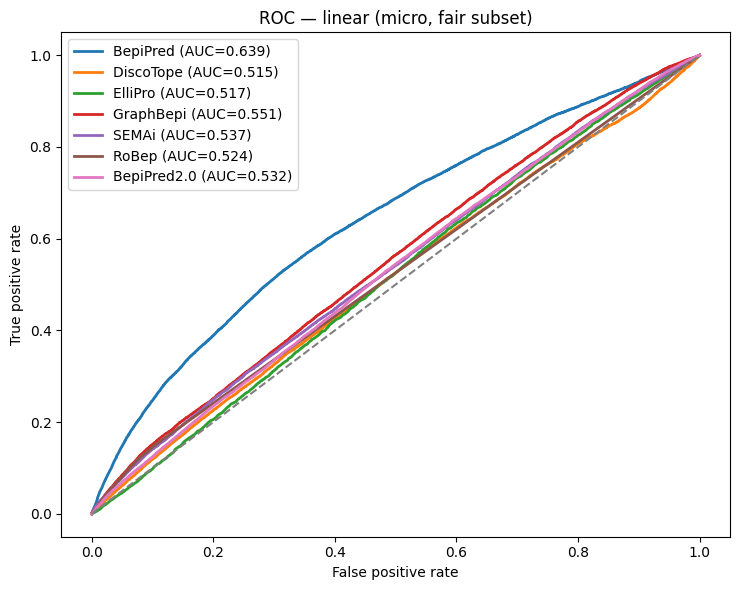

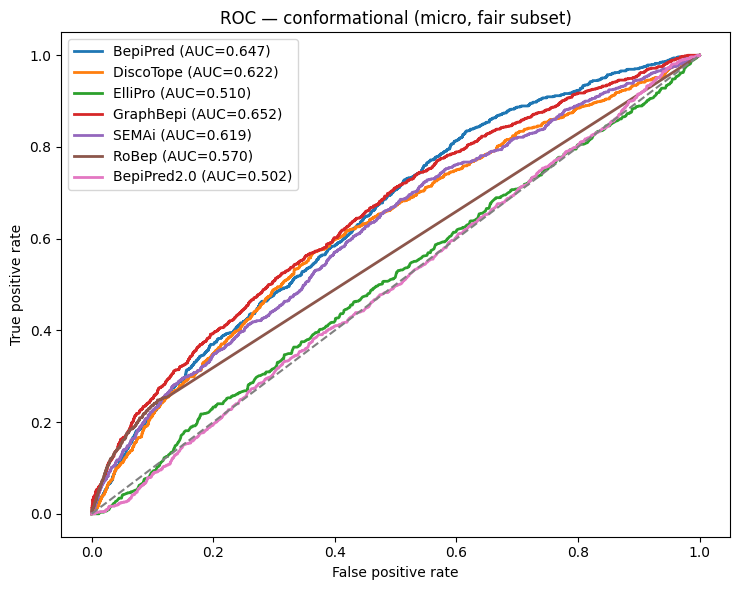

In [11]:
def plot_roc(df, epitope_type):
    sub = df[df["type"] == epitope_type]
    plt.figure(figsize=(7.5, 6))
    for model in MODEL_LIST:
        m = sub[sub["model"] == model]
        yt = m["y_true"].astype(int)
        if yt.nunique() < 2:
            continue
        s = m["score"].astype(float)
        fpr, tpr, _ = roc_curve(yt, s)
        plt.plot(fpr, tpr, linewidth=2, label=f"{model} (AUC={roc_auc_score(yt, s):.3f})")
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(f"ROC — {epitope_type} (micro, fair subset)")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_roc(master_fair, "linear")
plot_roc(master_fair, "conformational")


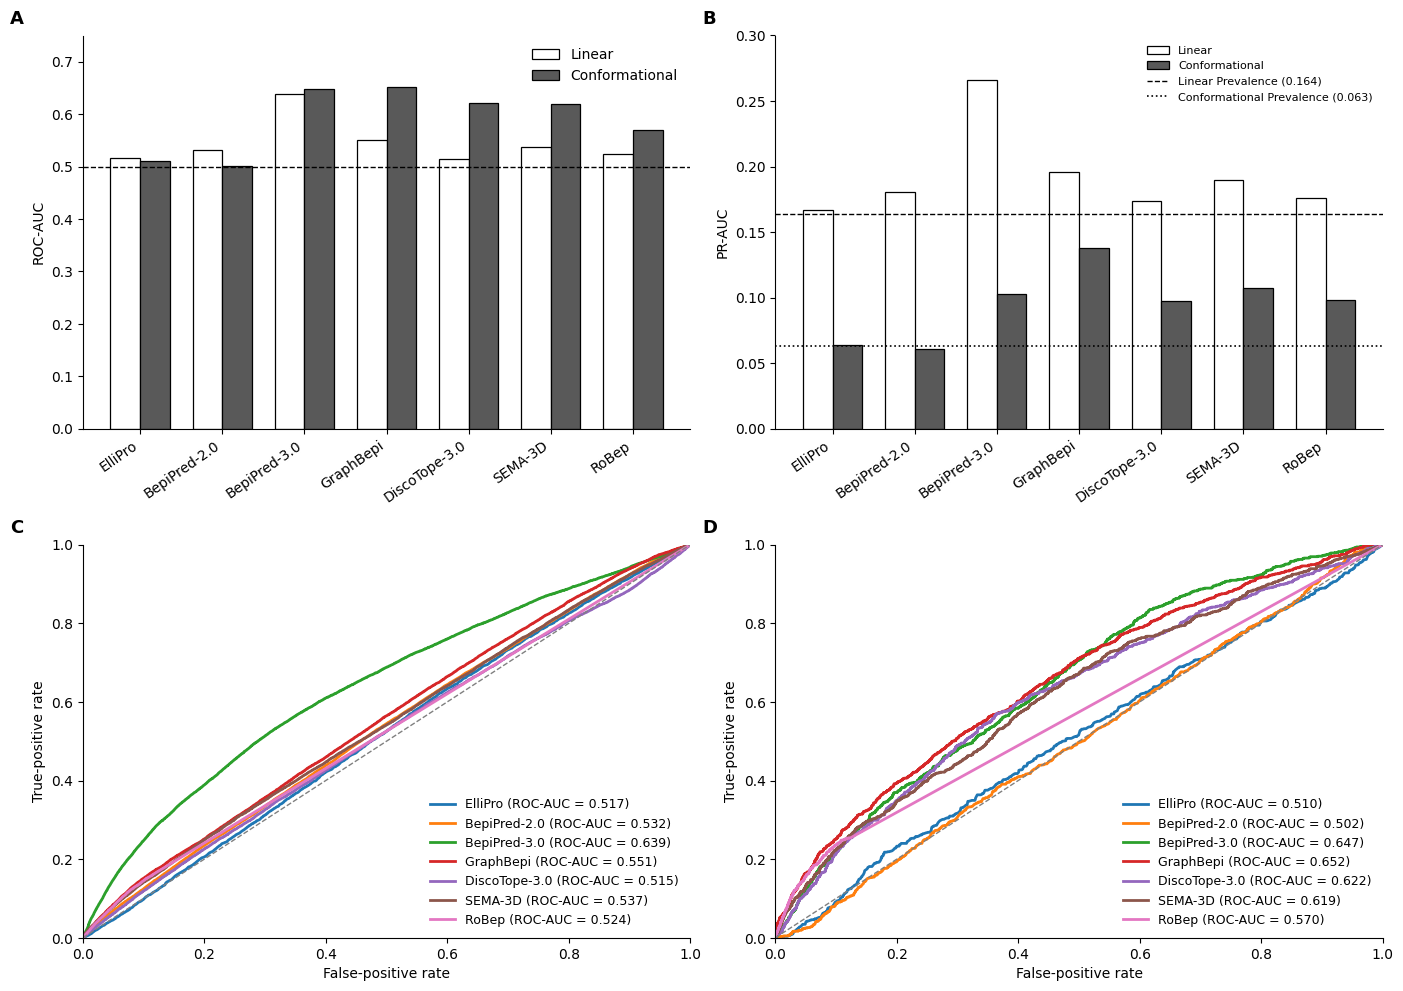

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.metrics import roc_curve, roc_auc_score

# -----------------------------
# Clean labels and plotting order
# -----------------------------
model_names = {
    "ElliPro": "ElliPro",
    "BepiPred2.0": "BepiPred-2.0",
    "BepiPred": "BepiPred-3.0",
    "GraphBepi": "GraphBepi",
    "DiscoTope": "DiscoTope-3.0",
    "SEMAi": "SEMA-3D",
    "RoBep": "RoBep",
}

predictor_order_raw = [
    "ElliPro",
    "BepiPred2.0",
    "BepiPred",
    "GraphBepi",
    "DiscoTope",
    "SEMAi",
    "RoBep",
]

predictor_order_clean = [model_names[m] for m in predictor_order_raw]

# Use the same colors for each predictor across both ROC panels
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
model_colors = {m: default_colors[i % len(default_colors)] for i, m in enumerate(predictor_order_raw)}

# -----------------------------
# Prepare bar-chart data
# -----------------------------
plot_df = tf_micro.copy()
plot_df["Predictor"] = plot_df["model"].replace(model_names)
plot_df["Epitope type"] = plot_df["type"].str.lower().map({
    "linear": "Linear",
    "conformational": "Conformational"
})

# prevalence baselines for PR-AUC
linear_prev = 0.164
conf_prev = 0.063

# -----------------------------
# Create 4-panel figure
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax1, ax2, ax3, ax4 = axes.flatten()

# -----------------------------
# Panel A: Micro-averaged ROC-AUC
# -----------------------------
x = np.arange(len(predictor_order_clean))
width = 0.36

for i, epitope_type in enumerate(["Linear", "Conformational"]):
    vals = (
        plot_df[plot_df["Epitope type"] == epitope_type]
        .set_index("Predictor")
        .reindex(predictor_order_clean)["ROC_AUC"]
        .values
    )
    offset = -width/2 if epitope_type == "Linear" else width/2
    facecolor = "white" if epitope_type == "Linear" else "0.35"

    ax1.bar(
        x + offset,
        vals,
        width=width,
        facecolor=facecolor,
        edgecolor="black",
        linewidth=0.9,
        label=epitope_type
    )

ax1.axhline(0.5, linestyle="--", color="black", linewidth=1)
ax1.set_ylabel("ROC-AUC")
ax1.set_xticks(x)
ax1.set_xticklabels(predictor_order_clean, rotation=35, ha="right")
ax1.set_ylim(0, 0.75)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.legend(frameon=False, title=None, loc="upper right")
ax1.text(-0.12, 1.03, "A", transform=ax1.transAxes, fontsize=13, fontweight="bold")

# -----------------------------
# Panel B: Micro-averaged PR-AUC
# -----------------------------
for i, epitope_type in enumerate(["Linear", "Conformational"]):
    vals = (
        plot_df[plot_df["Epitope type"] == epitope_type]
        .set_index("Predictor")
        .reindex(predictor_order_clean)["PR_AUC"]
        .values
    )
    offset = -width/2 if epitope_type == "Linear" else width/2
    facecolor = "white" if epitope_type == "Linear" else "0.35"

    ax2.bar(
        x + offset,
        vals,
        width=width,
        facecolor=facecolor,
        edgecolor="black",
        linewidth=0.9
    )

ax2.axhline(linear_prev, linestyle="--", color="black", linewidth=1)
ax2.axhline(conf_prev, linestyle=":", color="black", linewidth=1.2)
ax2.set_ylabel("PR-AUC")
ax2.set_xticks(x)
ax2.set_xticklabels(predictor_order_clean, rotation=35, ha="right")
ax2.set_ylim(0, 0.30)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

pr_legend_handles = [
    Patch(facecolor="white", edgecolor="black", linewidth=0.9, label="Linear"),
    Patch(facecolor="0.35", edgecolor="black", linewidth=0.9, label="Conformational"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1, label="Linear Prevalence (0.164)"),
    Line2D([0], [0], color="black", linestyle=":", linewidth=1.2, label="Conformational Prevalence (0.063)")
]
ax2.legend(handles=pr_legend_handles, frameon=False, title=None, loc="upper right", fontsize=8)
ax2.text(-0.12, 1.03, "B", transform=ax2.transAxes, fontsize=13, fontweight="bold")

# -----------------------------
# Helper function for ROC panels
# -----------------------------
def plot_roc_panel(ax, df, epitope_type):
    sub = df[df["type"] == epitope_type]

    for model in predictor_order_raw:
        m = sub[sub["model"] == model]
        if m.empty:
            continue

        yt = m["y_true"].astype(int)
        if yt.nunique() < 2:
            continue

        s = m["score"].astype(float)
        fpr, tpr, _ = roc_curve(yt, s)
        auc = roc_auc_score(yt, s)

        ax.plot(
            fpr,
            tpr,
            linewidth=2,
            color=model_colors[model],
            label=f"{model_names[model]} (ROC-AUC = {auc:.3f})"
        )

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    ax.set_xlabel("False-positive rate")
    ax.set_ylabel("True-positive rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=9, loc="lower right")

# -----------------------------
# Panel C: ROC curves, linear epitopes
# -----------------------------
plot_roc_panel(ax3, master_fair, "linear")
ax3.text(-0.12, 1.03, "C", transform=ax3.transAxes, fontsize=13, fontweight="bold")

# -----------------------------
# Panel D: ROC curves, conformational epitopes
# -----------------------------
plot_roc_panel(ax4, master_fair, "conformational")
ax4.text(-0.12, 1.03, "D", transform=ax4.transAxes, fontsize=13, fontweight="bold")

# -----------------------------
# Final layout and save
# -----------------------------
plt.tight_layout()

plt.savefig("figure_residue_level_performance_4panel.png", dpi=600, bbox_inches="tight")
plt.savefig("figure_residue_level_performance_4panel.pdf", bbox_inches="tight")

plt.show()

## 9. Region overlap (Jaccard / Dice)

Computed per protein on the **matched-budget** predictions so overlap reflects ranking, not
each tool's threshold. (Swap `pred_col="y_pred"` to inspect native-cutoff overlap.)

          type       model  mean_jaccard  mean_dice
conformational    BepiPred         0.064      0.110
conformational BepiPred2.0         0.038      0.066
conformational   DiscoTope         0.085      0.144
conformational     ElliPro         0.039      0.067
conformational   GraphBepi         0.100      0.165
conformational       RoBep         0.093      0.151
conformational       SEMAi         0.087      0.144
        linear    BepiPred         0.170      0.228
        linear BepiPred2.0         0.169      0.228
        linear   DiscoTope         0.167      0.232
        linear     ElliPro         0.160      0.215
        linear   GraphBepi         0.167      0.229
        linear       RoBep         0.161      0.215
        linear       SEMAi         0.163      0.221


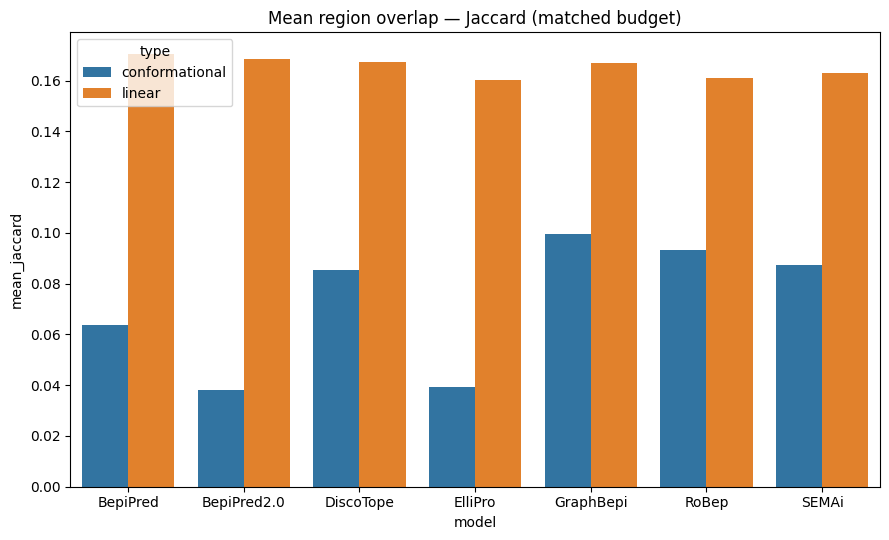

In [12]:
def overlap_table(df, pred_col):
    rows = []
    for (m, typ, org, prot), sub in df.groupby(["model", "type", "organism", "uniprot"]):
        true_set = set(sub.loc[sub.y_true == 1, "res_index"])
        if not true_set:
            continue
        pred_set = set(sub.loc[sub[pred_col] == 1, "res_index"])
        inter = len(true_set & pred_set)
        union = len(true_set | pred_set)
        denom = len(true_set) + len(pred_set)
        rows.append({
            "model": m, "type": typ, "organism": org, "uniprot": prot,
            "jaccard": inter / union if union else 0.0,
            "dice": (2 * inter / denom) if denom else 0.0,
        })
    return pd.DataFrame(rows)


overlap_df = overlap_table(master_fair, "y_pred_matched")
overlap_summary = (overlap_df.groupby(["type", "model"])
                   .agg(mean_jaccard=("jaccard", "mean"), mean_dice=("dice", "mean"))
                   .reset_index())
print(overlap_summary.round(3).to_string(index=False))

plt.figure(figsize=(9, 5.5))
sns.barplot(data=overlap_summary, x="model", y="mean_jaccard", hue="type")
plt.title("Mean region overlap — Jaccard (matched budget)")
plt.tight_layout()
plt.show()


## 10. Top-10 enrichment

Fraction of each protein's top-10 scoring residues that are true epitopes. Threshold-free
(uses ranking only). Random baseline = fair-subset prevalence per type (computed, not hard-coded).

          type       model  mean_top10
conformational    BepiPred       0.128
conformational BepiPred2.0       0.075
conformational   DiscoTope       0.150
conformational     ElliPro       0.033
conformational   GraphBepi       0.172
conformational       RoBep       0.175
conformational       SEMAi       0.206
        linear    BepiPred       0.247
        linear BepiPred2.0       0.219
        linear   DiscoTope       0.250
        linear     ElliPro       0.184
        linear   GraphBepi       0.238
        linear       RoBep       0.233
        linear       SEMAi       0.247

random baselines (fair-subset prevalence):
type
conformational    0.0629
linear            0.1635
Name: y_true, dtype: float64


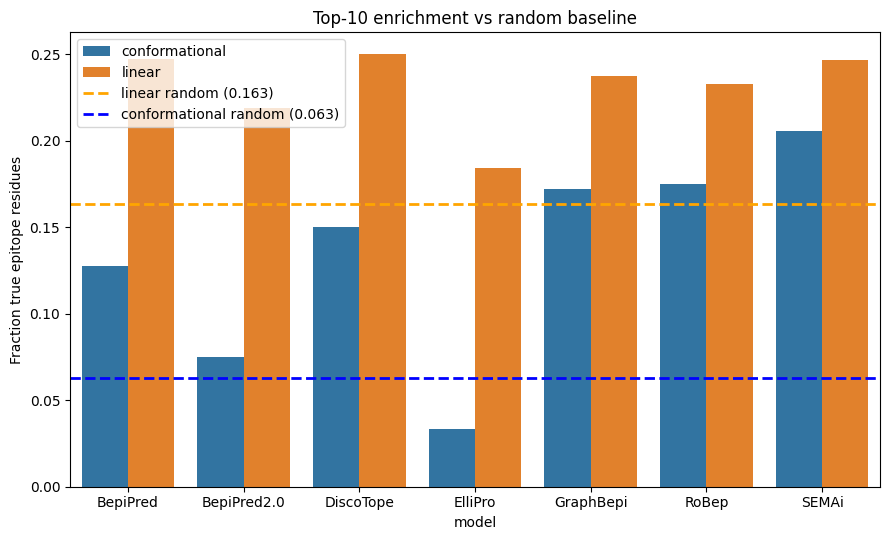

In [13]:
def topk_enrichment(df, k=10):
    rows = []
    for (m, typ, org, prot), sub in df.groupby(["model", "type", "organism", "uniprot"]):
        if len(sub) < k:
            continue
        top = sub.sort_values("score", ascending=False).head(k)
        rows.append({"model": m, "type": typ, "organism": org, "uniprot": prot,
                     "topk_true_fraction": top["y_true"].mean()})
    return pd.DataFrame(rows)


top10 = topk_enrichment(master_fair, k=10)
top10_summary = (top10.groupby(["type", "model"])
                 .agg(mean_top10=("topk_true_fraction", "mean")).reset_index())
baseline = master_fair.groupby("type")["y_true"].mean()

print(top10_summary.round(3).to_string(index=False))
print("\nrandom baselines (fair-subset prevalence):")
print(baseline.round(4))

plt.figure(figsize=(9, 5.5))
ax = sns.barplot(data=top10_summary, x="model", y="mean_top10", hue="type")
for typ, color in zip(TYPES, ["orange", "blue"]):
    if typ in baseline.index:
        ax.axhline(baseline[typ], ls="--", lw=2, color=color,
                   label=f"{typ} random ({baseline[typ]:.3f})")
plt.title("Top-10 enrichment vs random baseline")
plt.ylabel("Fraction true epitope residues")
plt.legend()
plt.tight_layout()
plt.show()


## 11. Confusion matrix

Parameterized by model, type, and operating point (label bug fixed; no longer pools types).

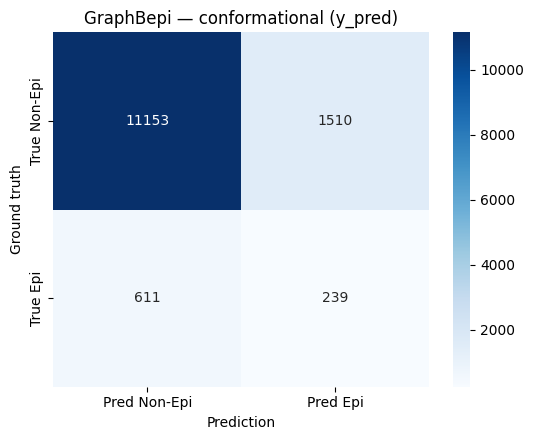

In [14]:
def plot_confusion(df, model, typ, pred_col="y_pred"):
    sub = df[(df.model == model) & (df.type == typ)]
    cm = confusion_matrix(sub["y_true"].astype(int), sub[pred_col].astype(int))
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred Non-Epi", "Pred Epi"],
                yticklabels=["True Non-Epi", "True Epi"])
    plt.title(f"{model} — {typ} ({pred_col})")
    plt.xlabel("Prediction")
    plt.ylabel("Ground truth")
    plt.tight_layout()
    plt.show()


plot_confusion(master_fair, "GraphBepi", "conformational", "y_pred")


## 12. Consensus (conformational)

Run on the conformational fair subset using **matched-budget** predictions so every model
contributes an equal budget (native cutoffs would let permissive models dominate the count).
The "consensus improves precision but reduces recall" claim requires **cumulative ≥k**
thresholding, not per-exact-k buckets — both are shown.

Per-bucket PPV (residues at exactly k agreeing):
 consensus_count  n_residues  n_true  ppv_in_bucket
               0       10209     440          0.043
               1        1915     173          0.090
               2         702      85          0.121
               3         350      70          0.200
               4         188      35          0.186
               5          82      29          0.354
               6          50      15          0.300
               7          17       3          0.176

Cumulative consensus (>= k models agree):
 min_models_agree  predicted_positives  precision  recall
                1                 3304      0.124   0.482
                2                 1389      0.171   0.279
                3                  687      0.221   0.179
                4                  337      0.243   0.096
                5                  149      0.315   0.055
                6                   67      0.269   0.021
                7                 

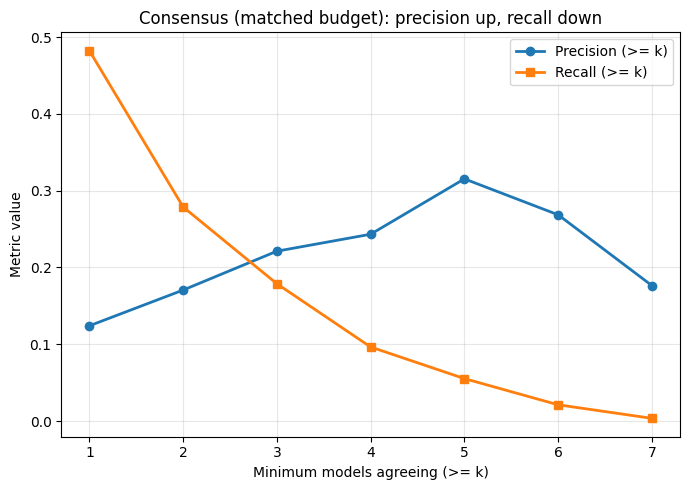

In [15]:
conf = master_fair[master_fair["type"] == "conformational"].copy()

pivot = conf.pivot_table(index=["uniprot", "res_index", "y_true"],
                         columns="model", values="y_pred_matched",
                         fill_value=0).astype(int)
pivot["consensus_count"] = pivot[MODEL_LIST].sum(axis=1)
cons = pivot.reset_index()
total_true = int(cons["y_true"].sum())

# per-bucket positive predictive value (descriptive)
bucket = (cons.groupby("consensus_count")
          .agg(n_residues=("y_true", "size"), n_true=("y_true", "sum"))
          .reset_index())
bucket["ppv_in_bucket"] = bucket["n_true"] / bucket["n_residues"]

# cumulative >= k
rows = []
for k in range(1, len(MODEL_LIST) + 1):
    sel = cons["consensus_count"] >= k
    pp = int(sel.sum())
    tp = int(cons.loc[sel, "y_true"].sum())
    rows.append({"min_models_agree": k, "predicted_positives": pp,
                 "precision": tp / pp if pp else np.nan,
                 "recall": tp / total_true if total_true else np.nan})
cum = pd.DataFrame(rows)

print("Per-bucket PPV (residues at exactly k agreeing):")
print(bucket.round(3).to_string(index=False))
print("\nCumulative consensus (>= k models agree):")
print(cum.round(3).to_string(index=False))

plt.figure(figsize=(7, 5))
plt.plot(cum["min_models_agree"], cum["precision"], marker="o", lw=2, label="Precision (>= k)")
plt.plot(cum["min_models_agree"], cum["recall"], marker="s", lw=2, label="Recall (>= k)")
plt.xlabel("Minimum models agreeing (>= k)")
plt.ylabel("Metric value")
plt.title("Consensus (matched budget): precision up, recall down")
plt.xticks(cum["min_models_agree"])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 13. Reporting notes for the thesis

- **Headline ranking:** threshold-free (PR-AUC primary, ROC-AUC secondary), micro and macro.
- **Threshold metrics:** always state the operating point. Native-cutoff numbers describe a
  tool's default behavior, *not* its skill, and must not be used to rank models.
- **Fair subset:** report the protein/residue counts (Section 4) so the comparison set is explicit.
- **Cross-type evaluation:** state which (model × epitope-type) pairs are native vs off-label
  (e.g. DiscoTope on linear truth is off-label).
- **Open item:** confirm every model's `score` is oriented higher = more epitope-like
  (Section 3 flags any pooled AUC < 0.5).


residues with pLDDT attached: 100.0%  (0 missing)

=== pLDDT band composition (fair subset) ===
          type        plddt_band  residues  epitope_residues  prevalence
conformational    very low (<50)     13559               280      0.0207
conformational       low (50-70)      6307               252      0.0400
conformational confident (70-90)     14434               784      0.0543
conformational  very high (>=90)     60291              4634      0.0769
        linear    very low (<50)    116508             17318      0.1486
        linear       low (50-70)     62832             10388      0.1653
        linear confident (70-90)    160230             25382      0.1584
        linear  very high (>=90)    496678             83629      0.1684

=== micro ROC-AUC within pLDDT band (linear) ===
plddt_band   confident (70-90)  low (50-70)  very high (>=90)  very low (<50)
model                                                                        
BepiPred                 0.672        0.6

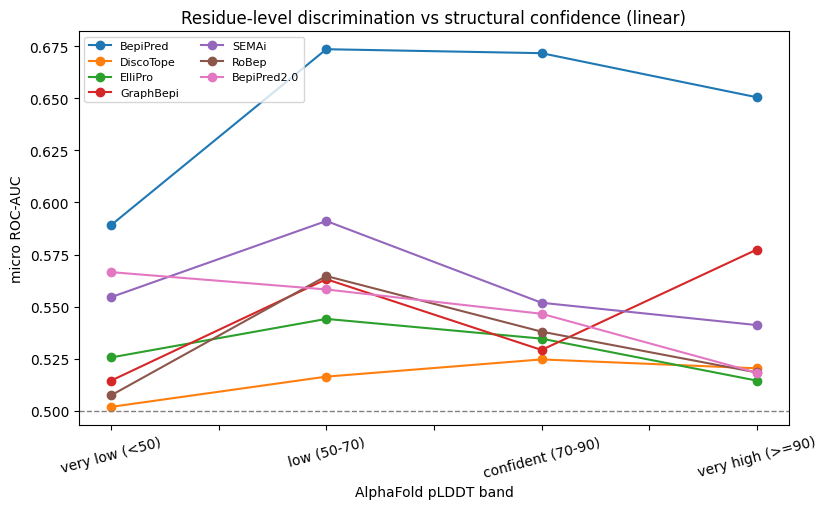

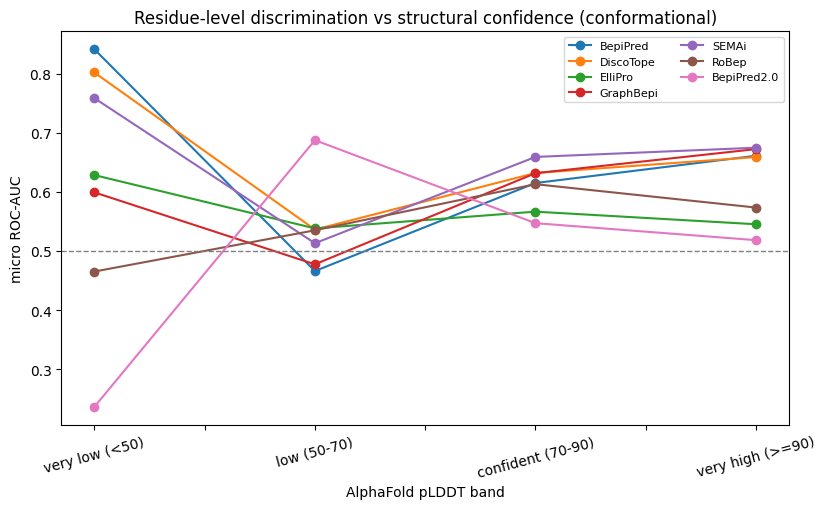

In [16]:
# ============================================================
# RQ2 — Sensitivity of predictor performance to AlphaFold pLDDT
# Append to notebook 06 AFTER master_fair is built.
# Reuses: parse_structure (from nb 07), MODEL_LIST, master_fair.
# ============================================================
from pathlib import Path
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

STRUCTURE_BASE = Path("../structures")   # same base used in nb 07

# ---- 1. attach per-residue pLDDT to the fair-subset table -----------------
def load_plddt_map():
    """Return {(uniprot,res_index): plddt} from the AlphaFold PDBs."""
    m = {}
    for org in ORGS:
        for typ in TYPES:
            d = STRUCTURE_BASE / org / typ
            if not d.exists():
                continue
            for pdb in sorted(d.glob("*.pdb")):
                # skip PDB-derived experimental files (name_XXXX.pdb); AlphaFold only
                if "_" in pdb.stem:
                    continue
                uni = pdb.stem
                with open(pdb) as fh:
                    for line in fh:
                        if not line.startswith("ATOM") or line[12:16].strip() != "CA":
                            continue
                        ri = int(line[22:26])
                        m[(uni, ri)] = float(line[60:66])
    return m

plddt_map = load_plddt_map()
mf = master_fair.copy()
mf["plddt"] = [plddt_map.get((u, int(r)), np.nan)
               for u, r in zip(mf["uniprot"], mf["res_index"])]

missing = mf["plddt"].isna().mean()
print(f"residues with pLDDT attached: {(1-missing)*100:.1f}%  "
      f"({int(mf['plddt'].isna().sum())} missing)")
# residues without pLDDT (e.g. the excluded experimental antigen) are dropped
mf = mf.dropna(subset=["plddt"]).copy()

# ---- 2. define pLDDT bands (AlphaFold's own confidence bands) --------------
# very low <50, low 50-70, confident 70-90, very high >=90
bins   = [0, 50, 70, 90, 100.01]
labels = ["very low (<50)", "low (50-70)", "confident (70-90)", "very high (>=90)"]
mf["plddt_band"] = pd.cut(mf["plddt"], bins=bins, labels=labels, right=False)

# ---- 3. band composition, overall and by epitope status -------------------
comp = (mf.groupby(["type", "plddt_band"], observed=True)
          .agg(residues=("y_true", "size"),
               epitope_residues=("y_true", "sum"))
          .reset_index())
comp["prevalence"] = (comp["epitope_residues"] / comp["residues"]).round(4)
print("\n=== pLDDT band composition (fair subset) ===")
print(comp.to_string(index=False))

# ---- 4. micro ROC-AUC / PR-AUC within each band ---------------------------
def auc_within_bands(df):
    rows = []
    for (typ, m, band), sub in df.groupby(["type", "model", "plddt_band"], observed=True):
        yt = sub["y_true"].astype(int)
        if yt.nunique() < 2 or len(sub) < 50:      # skip degenerate/tiny cells
            roc = pr = np.nan
        else:
            s = sub["score"].astype(float)
            roc = roc_auc_score(yt, s)
            pr  = average_precision_score(yt, s)
        rows.append({"type": typ, "model": m, "plddt_band": band,
                     "residues": len(sub), "prevalence": round(yt.mean(), 4),
                     "ROC_AUC": roc, "PR_AUC": pr})
    return pd.DataFrame(rows)

band_auc = auc_within_bands(mf)
print("\n=== micro ROC-AUC within pLDDT band (linear) ===")
print(band_auc.query("type=='linear'")
        .pivot(index="model", columns="plddt_band", values="ROC_AUC")
        .reindex(MODEL_LIST).round(3).to_string())
print("\n=== micro ROC-AUC within pLDDT band (conformational) ===")
print(band_auc.query("type=='conformational'")
        .pivot(index="model", columns="plddt_band", values="ROC_AUC")
        .reindex(MODEL_LIST).round(3).to_string())

# ---- 5. slope: does AUC change with confidence? ---------------------------
# regress per-residue correctness proxy is not linear; instead summarise the
# high-vs-low gap that the paper will quote.
def band_gap(df, typ, hi="very high (>=90)", lo="low (50-70)"):
    p = (df.query("type==@typ")
           .pivot(index="model", columns="plddt_band", values="ROC_AUC"))
    if hi in p and lo in p:
        out = (p[[lo, hi]].reindex(MODEL_LIST).copy())
        out["gap (high - low)"] = (out[hi] - out[lo]).round(3)
        return out.round(3)
    return None

print("\n=== linear: high-confidence vs low-confidence ROC-AUC ===")
print(band_gap(band_auc, "linear").to_string())
print("\n=== conformational: high-confidence vs low-confidence ROC-AUC ===")
print(band_gap(band_auc, "conformational").to_string())

# ---- 6. figure: ROC-AUC vs pLDDT band, per predictor ----------------------
import matplotlib.pyplot as plt
band_order = labels
for typ in TYPES:
    piv = (band_auc.query("type==@typ")
             .pivot(index="plddt_band", columns="model", values="ROC_AUC")
             .reindex(band_order))
    ax = piv[MODEL_LIST].plot(marker="o", figsize=(8.4, 5.2))
    ax.axhline(0.5, ls="--", c="grey", lw=1)
    ax.set_ylabel("micro ROC-AUC"); ax.set_xlabel("AlphaFold pLDDT band")
    ax.set_title(f"Residue-level discrimination vs structural confidence ({typ})")
    ax.legend(title=None, fontsize=8, ncol=2)
    plt.xticks(rotation=15); plt.tight_layout(); plt.show()

In [17]:
# conformational: PR-AUC vs each band's own prevalence baseline + positive counts
typ = "conformational"
pos = (mf.query("type==@typ").groupby("plddt_band", observed=True)["y_true"]
         .agg(residues="size", positives="sum", prevalence="mean").round(4))
print("positives per band:\n", pos.to_string(), "\n")

pr = (band_auc.query("type==@typ")
        .pivot(index="model", columns="plddt_band", values="PR_AUC")
        .reindex(MODEL_LIST).round(3))
# express PR-AUC as lift over each band's baseline prevalence
base = pos["prevalence"]
lift = pr.divide(base, axis=1).round(2)
print("PR-AUC:\n", pr.to_string())
print("\nPR-AUC as lift over band baseline (values >1 = better than chance):\n", lift.to_string())

positives per band:
                    residues  positives  prevalence
plddt_band                                        
very low (<50)        13559        280      0.0207
low (50-70)            6307        252      0.0400
confident (70-90)     14434        784      0.0543
very high (>=90)      60291       4634      0.0769 

PR-AUC:
 plddt_band   confident (70-90)  low (50-70)  very high (>=90)  very low (<50)
model                                                                        
BepiPred                 0.082        0.043             0.127           0.076
DiscoTope                0.088        0.108             0.129           0.083
ElliPro                  0.079        0.046             0.091           0.029
GraphBepi                0.151        0.037             0.172           0.025
SEMAi                    0.128        0.066             0.166           0.044
RoBep                    0.101        0.043             0.130           0.021
BepiPred2.0              0.066        

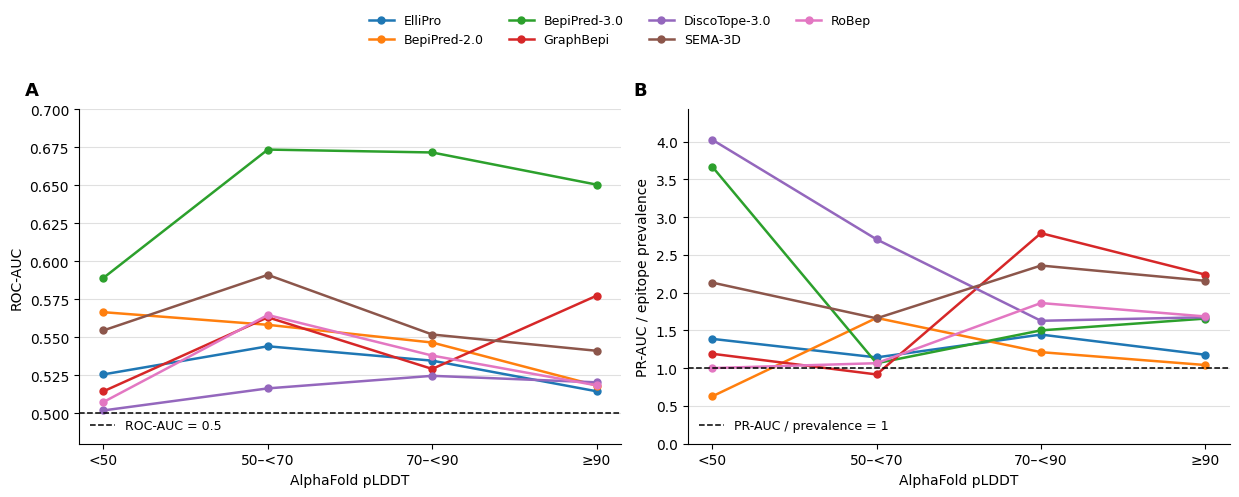

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------------------------------------------------
# Publication-ready pLDDT performance figure
# A: Linear ROC-AUC
# B: Conformational PR-AUC relative to band prevalence
# ---------------------------------------------------------

model_names = {
    "ElliPro": "ElliPro",
    "BepiPred2.0": "BepiPred-2.0",
    "BepiPred": "BepiPred-3.0",
    "GraphBepi": "GraphBepi",
    "DiscoTope": "DiscoTope-3.0",
    "SEMAi": "SEMA-3D",
    "RoBep": "RoBep"
}

predictor_order = [
    "ElliPro",
    "BepiPred2.0",
    "BepiPred",
    "GraphBepi",
    "DiscoTope",
    "SEMAi",
    "RoBep"
]

band_order = [
    "very low (<50)",
    "low (50-70)",
    "confident (70-90)",
    "very high (>=90)"
]

band_labels = [
    "<50",
    "50–<70",
    "70–<90",
    "≥90"
]

# Same predictor colours used throughout the manuscript
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

model_colors = {
    m: default_colors[i % len(default_colors)]
    for i, m in enumerate(predictor_order)
}

# ---------------------------------------------------------
# Panel A: linear ROC-AUC
# ---------------------------------------------------------

linear_roc = (
    band_auc.query("type == 'linear'")
    .pivot(index="plddt_band", columns="model", values="ROC_AUC")
    .reindex(band_order)
)

# ---------------------------------------------------------
# Panel B: conformational PR-AUC relative to prevalence
# ---------------------------------------------------------

conf_pos = (
    mf.query("type == 'conformational'")
    .groupby("plddt_band", observed=True)["y_true"]
    .agg(
        residues="size",
        positives="sum",
        prevalence="mean"
    )
    .reindex(band_order)
)

conf_pr = (
    band_auc.query("type == 'conformational'")
    .pivot(index="plddt_band", columns="model", values="PR_AUC")
    .reindex(band_order)
)

conf_lift = conf_pr.div(conf_pos["prevalence"], axis=0)

# ---------------------------------------------------------
# Create figure
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(12.5, 4.8)
)

ax1, ax2 = axes
x = np.arange(len(band_order))

# ---------------------------------------------------------
# A. Linear ROC-AUC
# ---------------------------------------------------------

for m in predictor_order:
    ax1.plot(
        x,
        linear_roc[m].values,
        marker="o",
        markersize=5,
        linewidth=1.8,
        color=model_colors[m],
        label=model_names[m]
    )

ax1.axhline(
    0.5,
    linestyle="--",
    linewidth=1.1,
    color="black"
)

ax1.set_xticks(x)
ax1.set_xticklabels(band_labels)
ax1.set_xlabel("AlphaFold pLDDT")
ax1.set_ylabel("ROC-AUC")

ax1.set_ylim(
    0.48,
    max(0.70, np.nanmax(linear_roc.values) + 0.02)
)

ax1.grid(
    axis="y",
    color="0.88",
    linewidth=0.8
)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

ax1.text(
    -0.10,
    1.03,
    "A",
    transform=ax1.transAxes,
    fontsize=13,
    fontweight="bold",
    va="bottom"
)

# Reference-line legend for panel A
roc_reference = Line2D(
    [0], [0],
    color="black",
    linestyle="--",
    linewidth=1.1,
    label="ROC-AUC = 0.5"
)

ax1.legend(
    handles=[roc_reference],
    frameon=False,
    fontsize=9,
    loc="lower left"
)

# ---------------------------------------------------------
# B. Conformational PR-AUC relative to prevalence
# ---------------------------------------------------------

for m in predictor_order:
    ax2.plot(
        x,
        conf_lift[m].values,
        marker="o",
        markersize=5,
        linewidth=1.8,
        color=model_colors[m],
        label=model_names[m]
    )

ax2.axhline(
    1,
    linestyle="--",
    linewidth=1.1,
    color="black"
)

ax2.set_xticks(x)
ax2.set_xticklabels(band_labels)
ax2.set_xlabel("AlphaFold pLDDT")
ax2.set_ylabel("PR-AUC / epitope prevalence")

ax2.set_ylim(
    0,
    np.nanmax(conf_lift.values) * 1.10
)

ax2.grid(
    axis="y",
    color="0.88",
    linewidth=0.8
)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

ax2.text(
    -0.10,
    1.03,
    "B",
    transform=ax2.transAxes,
    fontsize=13,
    fontweight="bold",
    va="bottom"
)

# Reference-line legend for panel B
pr_reference = Line2D(
    [0], [0],
    color="black",
    linestyle="--",
    linewidth=1.1,
    label="PR-AUC / prevalence = 1"
)

ax2.legend(
    handles=[pr_reference],
    frameon=False,
    fontsize=9,
    loc="lower left"
)

# ---------------------------------------------------------
# Shared predictor legend
# ---------------------------------------------------------

predictor_handles = [
    Line2D(
        [0], [0],
        color=model_colors[m],
        marker="o",
        markersize=5,
        linewidth=1.8,
        label=model_names[m]
    )
    for m in predictor_order
]

fig.legend(
    handles=predictor_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=4,
    frameon=False,
    fontsize=9
)

plt.tight_layout(rect=[0, 0, 1, 0.91])

plt.savefig(
    "performance_across_plddt.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "performance_across_plddt.pdf",
    bbox_inches="tight"
)

plt.show()

In [24]:
cum.to_csv("conformational_consensus.csv", index=False)